In [1]:
import sklearn as sk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [2]:
pip install ucimlrepo

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [7]:
df = pd.concat([breast_cancer.data.features, breast_cancer.data.targets], axis=1)
print(df.head())

categorical_val = []
continous_val = []

for column in df.columns:
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)


print("\nVariables categóricas:", categorical_val)
print("Variables continuas:", continous_val)


   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1809             0.05883  ...     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.

In [8]:
if 'Diagnosis' in categorical_val:
    categorical_val.remove('Diagnosis')
dataset = pd.get_dummies(df, columns=categorical_val, dtype=int)

In [9]:
from sklearn.preprocessing import StandardScaler

col_to_scale = continous_val

scaler = StandardScaler()

dataset[col_to_scale] = scaler.fit_transform(dataset[col_to_scale])

print(dataset[col_to_scale].head())

    radius1  texture1  perimeter1     area1  smoothness1  compactness1  \
0  1.097064 -2.073335    1.269934  0.984375     1.568466      3.283515   
1  1.829821 -0.353632    1.685955  1.908708    -0.826962     -0.487072   
2  1.579888  0.456187    1.566503  1.558884     0.942210      1.052926   
3 -0.768909  0.253732   -0.592687 -0.764464     3.283553      3.402909   
4  1.750297 -1.151816    1.776573  1.826229     0.280372      0.539340   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...   radius3  \
0    2.652874         2.532475   2.217515            2.255747  ...  1.886690   
1   -0.023846         0.548144   0.001392           -0.868652  ...  1.805927   
2    1.363478         2.037231   0.939685           -0.398008  ...  1.511870   
3    1.915897         1.451707   2.867383            4.910919  ... -0.281464   
4    1.371011         1.428493  -0.009560           -0.562450  ...  1.298575   

   texture3  perimeter3     area3  smoothness3  compactness3  concavity3  

In [10]:
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Métricas de evaluación:
Accuracy: 0.9064327485380117
Precision: 1.0
Recall: 0.75
F1 score: 0.8571428571428571


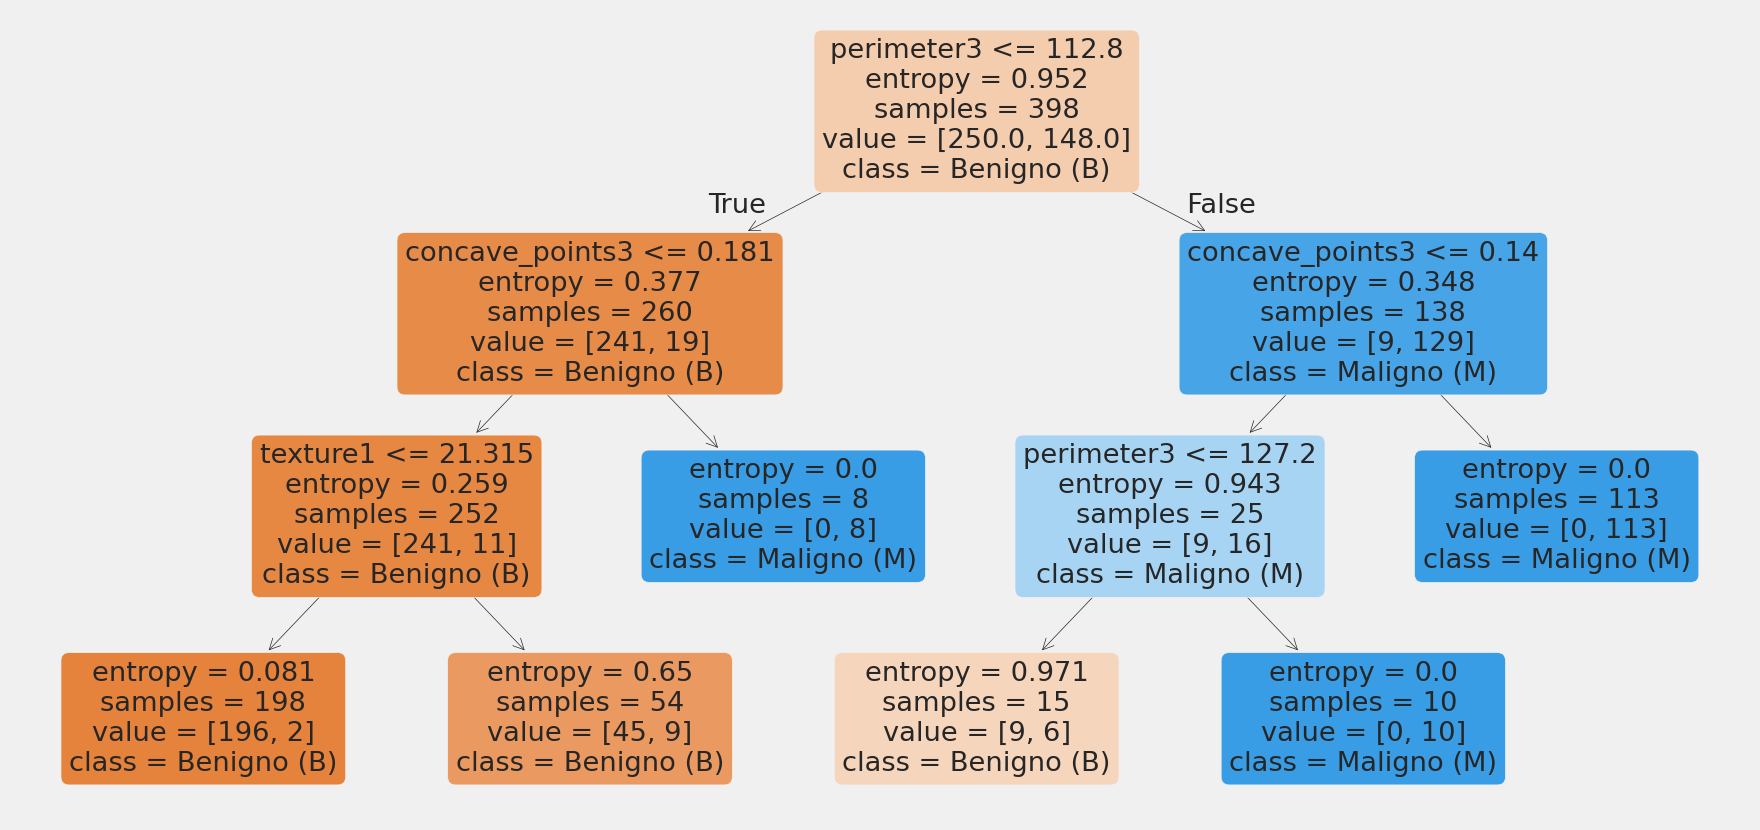

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

tree = DecisionTreeClassifier(
    class_weight=None,
    criterion='entropy',
    max_depth=3,
    min_samples_leaf=7,
    min_samples_split=2
)
tree.fit(X_train, y_train_encoded)

y_pred = tree.predict(X_test)


print("\nMétricas de evaluación:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred))
print("Recall:", recall_score(y_test_encoded, y_pred))
print("F1 score:", f1_score(y_test_encoded, y_pred))

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(tree,
          feature_names=X.columns,
          class_names=['Benigno (B)', 'Maligno (M)'],
          filled=True,
          rounded=True)
plt.show()

In [19]:

from sklearn.ensemble import RandomForestClassifier

print("=== RANDOM FOREST ===")

rand_forest = RandomForestClassifier(
    bootstrap=True,
    class_weight=None,
    criterion='gini',
    max_depth=3,
    max_features=0.3,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=10,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    n_estimators=1000,
    random_state=42
)

rand_forest.fit(X_train, y_train_encoded)


p_rf = rand_forest.predict(X_test)


print("Métricas Random Forest:")
print("Accuracy:", accuracy_score(y_test_encoded, p_rf))
print("F1 score:", f1_score(y_test_encoded, p_rf))
print("Precision:", precision_score(y_test_encoded, p_rf))
print("Recall:", recall_score(y_test_encoded, p_rf))

=== RANDOM FOREST ===
Métricas Random Forest:
Accuracy: 0.9532163742690059
F1 score: 0.9344262295081968
Precision: 0.9827586206896551
Recall: 0.890625


In [20]:
from sklearn.svm import SVC

print("=== SUPPORT VECTOR MACHINE ===")

svm_model = SVC(
    C=2,
    cache_size=200,
    class_weight=None,
    coef0=0.0,
    decision_function_shape='ovr',
    degree=3,
    gamma=0.001,
    kernel='rbf',
    max_iter=-1,
    random_state=42
)


svm_model.fit(X_train, y_train_encoded)

p_svm = svm_model.predict(X_test)

print("Métricas SVM:")
print("Accuracy:", accuracy_score(y_test_encoded, p_svm))
print("F1 score:", f1_score(y_test_encoded, p_svm))
print("Precision:", precision_score(y_test_encoded, p_svm))
print("Recall:", recall_score(y_test_encoded, p_svm))

=== SUPPORT VECTOR MACHINE ===
Métricas SVM:
Accuracy: 0.9298245614035088
F1 score: 0.9016393442622951
Precision: 0.9482758620689655
Recall: 0.859375


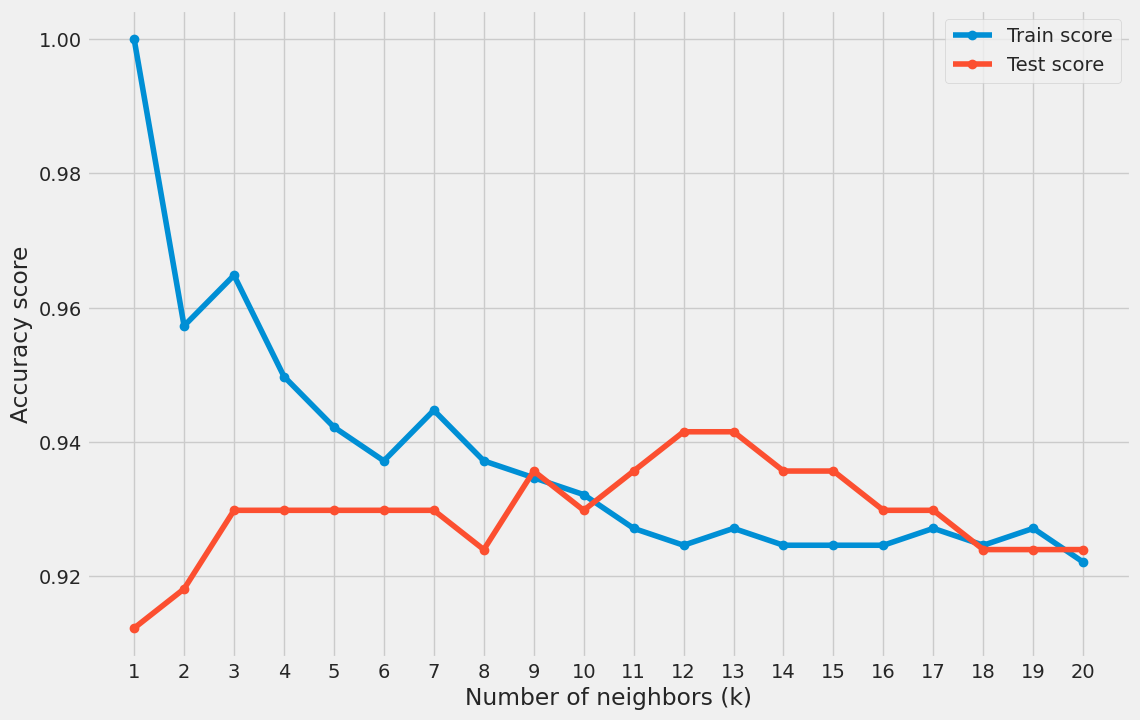

Maximum KNN accuracy on the test data: 0.9415 at k=12

Métricas con k=10:
Accuracy: 0.9298245614035088
Precision: 0.9814814814814815
Recall: 0.828125
F1 score: 0.8983050847457628


In [17]:
from sklearn.neighbors import KNeighborsClassifier

train_score = []
test_score = []
neighbors = range(1, 21)

for k in neighbors:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    train_score.append(accuracy_score(y_train, model.predict(X_train)))
    test_score.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(12, 8))
plt.plot(neighbors, train_score, label="Train score", marker='o')
plt.plot(neighbors, test_score, label="Test score", marker='o')
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy score")
plt.legend()
plt.grid(True)
plt.show()


print(f"Maximum KNN accuracy on the test data: {max(test_score):.4f} at k={test_score.index(max(test_score))+1}")

knn_classifier = KNeighborsClassifier(n_neighbors=10)
knn_classifier.fit(X_train, y_train)
p_knn = knn_classifier.predict(X_test)


print("\nMétricas con k=10:")
print("Accuracy:", accuracy_score(y_test, p_knn))
print("Precision:", precision_score(y_test, p_knn, pos_label='M'))
print("Recall:", recall_score(y_test, p_knn, pos_label='M'))
print("F1 score:", f1_score(y_test, p_knn, pos_label='M'))

In [18]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, p_knn))

[[106   1]
 [ 11  53]]


In [21]:
from sklearn.naive_bayes import GaussianNB

GBmodel = GaussianNB()

GBmodel.fit(X_train, y_train_encoded)

p_GB = GBmodel.predict(X_test)

print("Métricas Naive Bayes:")
print("Accuracy:", accuracy_score(y_test_encoded, p_GB))
print("F1 score:", f1_score(y_test_encoded, p_GB))
print("Precision:", precision_score(y_test_encoded, p_GB))
print("Recall:", recall_score(y_test_encoded, p_GB))

Métricas Naive Bayes:
Accuracy: 0.935672514619883
F1 score: 0.907563025210084
Precision: 0.9818181818181818
Recall: 0.84375


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

clf_optimo = RandomForestClassifier(random_state=42)

parameters = {
    'n_estimators': [10, 20, 30, 50],
    'max_features': [0.2, 0.3, 0.5],
    'criterion': ['entropy', 'gini'],
    'max_depth': [2, 3, 5, 10],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 5, 8]
}

acc_scorer = make_scorer(accuracy_score)

grid_obj = GridSearchCV(
    clf_optimo,
    parameters,
    scoring=acc_scorer)
grid_obj = grid_obj.fit(X_train, y_train_encoded)

clf_optimo = grid_obj.best_estimator_
clf_optimo = grid_obj.fit(X_train, y_train_encoded)
predictions_optimo = clf_optimo.predict(X_test)

print(f"\nMétricas Random Forest Optimizado:")
print("Accuracy:", accuracy_score(y_test_encoded, predictions_optimo))
print("F1 score:", f1_score(y_test_encoded, predictions_optimo))
print("Precision:", precision_score(y_test_encoded, predictions_optimo))
print("Recall:", recall_score(y_test_encoded, predictions_optimo))


Métricas Random Forest Optimizado:
Accuracy: 0.9707602339181286
F1 score: 0.959349593495935
Precision: 1.0
Recall: 0.921875


**Comparando con CompStats**

In [25]:
pip install CompStats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00


In [26]:
import sklearn
from CompStats import performance, plot_performance
from CompStats import difference, plot_difference
from CompStats import all_differences, difference_p_value
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import f1_score
import pandas as pd

In [27]:
concentrado = pd.DataFrame()
concentrado['Decision Tree'] = y_pred
concentrado['Random Forest'] = p_rf
concentrado['Random Forest Optimizado'] = predictions_optimo
concentrado['SVM'] = p_svm
concentrado['NaiveB'] = p_GB

concentrado['y'] = list(y_test_encoded)

concentrado

,Decision Tree,Random Forest,Random Forest Optimizado,SVM,NaiveB,y
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
166,0,0,0,0,0,0
167,1,0,1,0,0,1
168,0,0,1,0,0,1
169,0,0,0,0,0,0


100%|██████████| 6/6 [00:31<00:00,  5.22s/it]


{'best': 'Random Forest Optimizado'}

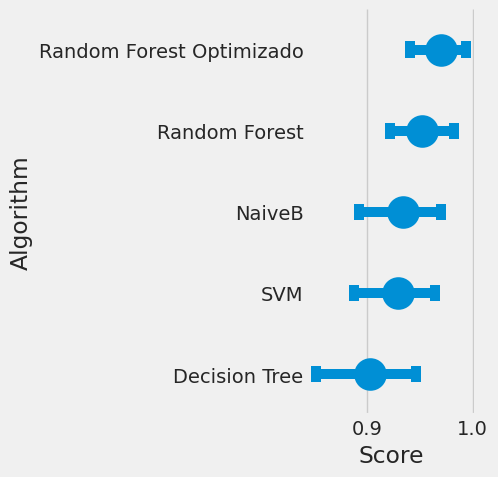

In [30]:
score = lambda y, hy: f1_score(y, hy, average='weighted')
perf = performance(concentrado, score=score, num_samples=1000)
face_grid = plot_performance(perf)
diff = difference(perf)
diff.info

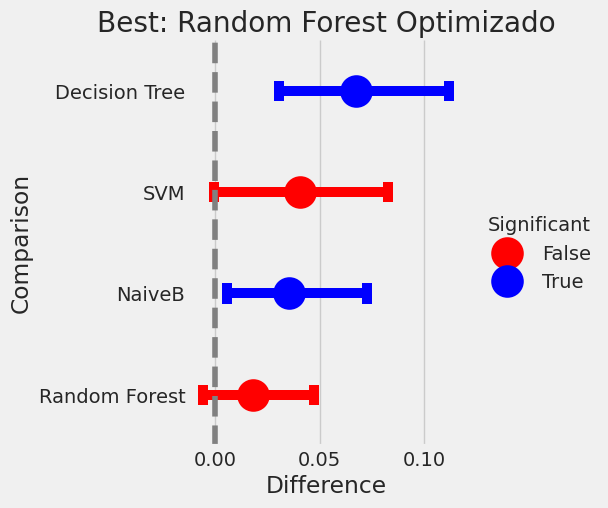

In [31]:
face_grid_diff = plot_difference(diff)

**Comparación de rendimiento entre todos los modelos**

In [29]:
all_diff = all_differences(perf)
p_values = difference_p_value(all_diff)
p_values

{'Random Forest Optimizado - Random Forest': np.float64(0.106),
 'Random Forest Optimizado - NaiveB': np.float64(0.024),
 'Random Forest Optimizado - SVM': np.float64(0.028),
 'Random Forest Optimizado - Decision Tree': np.float64(0.002),
 'Random Forest - NaiveB': np.float64(0.12),
 'Random Forest - SVM': np.float64(0.082),
 'Random Forest - Decision Tree': np.float64(0.01),
 'NaiveB - SVM': np.float64(0.351),
 'NaiveB - Decision Tree': np.float64(0.036),
 'SVM - Decision Tree': np.float64(0.155)}